In [2]:
import pandas as pd
import numpy as np
np.set_printoptions(linewidth=np.inf)
import matplotlib.pyplot as plt

In [3]:
filenames = ['time2_trilha1_post_n_DWT_PCA1.csv','time2_trilha1_post_n_savgol_PCA.csv','time2_trilha1_10-11_16-42-40CatBoost.csv',
             'time2_trilha1_autoDWTCNN_n.csv','time2_trilha1_DWTcurva_PCA_2.csv','time2_trilha1_RF_post_n.csv','time2_trilha1_autoDWTPCA.csv']
y = np.zeros((len(filenames),1000))
for i,filename in enumerate(filenames):
     y[i] = np.array(pd.read_csv('./submissions/'+filename, sep='\t').drop('CPMG',axis=1)).T
np.corrcoef(y)

array([[1.        , 0.99553804, 0.97189612, 0.96907122, 0.97729817, 0.98506944, 0.98373036],
       [0.99553804, 1.        , 0.96737865, 0.96325872, 0.97402247, 0.98014128, 0.97938356],
       [0.97189612, 0.96737865, 1.        , 0.98512955, 0.95550464, 0.96416811, 0.9599219 ],
       [0.96907122, 0.96325872, 0.98512955, 1.        , 0.95660865, 0.96288311, 0.95941038],
       [0.97729817, 0.97402247, 0.95550464, 0.95660865, 1.        , 0.96298212, 0.99135635],
       [0.98506944, 0.98014128, 0.96416811, 0.96288311, 0.96298212, 1.        , 0.96765297],
       [0.98373036, 0.97938356, 0.9599219 , 0.95941038, 0.99135635, 0.96765297, 1.        ]])

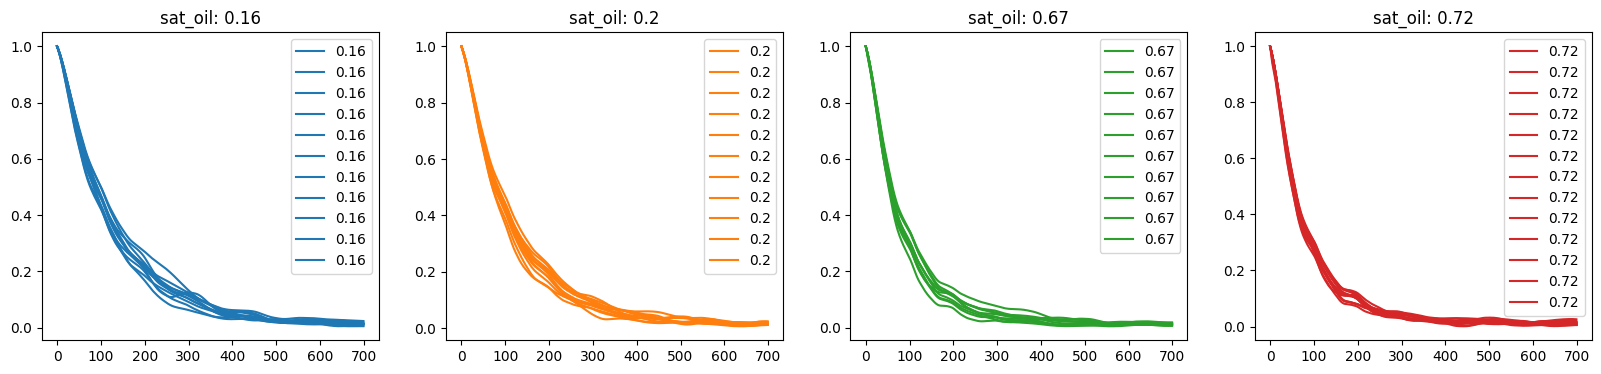

In [4]:
train_df = pd.read_csv('data_train_post_n_smoothing.csv', sep="\t")
#len(np.sort(train_df['y'].unique())) # 81, all values
cmap = plt.cm.tab10
fig, axes = plt.subplots(1,4, figsize=(20,4))
for i,ax in enumerate(axes):
    sat_oil = np.round(np.random.random()*.8,2)
    sel_train_df = train_df[train_df['y']==sat_oil]
    for j in range(len(sel_train_df)):
        ax.plot(range(700),sel_train_df.iloc[j,:-1], c=cmap(i%10), label=str(sat_oil))
    ax.set_title(f"sat_oil: {sat_oil}")
    ax.legend()
plt.show();

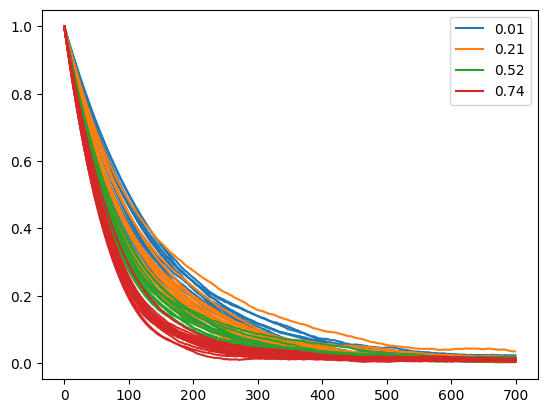

In [5]:
train_df = pd.read_csv('data_train_post_n_savgol.csv', sep="\t")
cmap = plt.cm.tab10

for i,sat_oil in enumerate(np.sort(np.round(np.random.random(4)*.8,2))):
    sel_train_df = train_df[train_df['y']==sat_oil]
    plt.plot(range(700),sel_train_df.iloc[0,:-1], c=cmap(i%10), label=str(sat_oil))
    for j in range(1,len(sel_train_df)):
        plt.plot(range(700),sel_train_df.iloc[j,:-1], c=cmap(i%10))
# plt.title(f"sat_oil: {sat_oil}")
plt.legend()
plt.show();

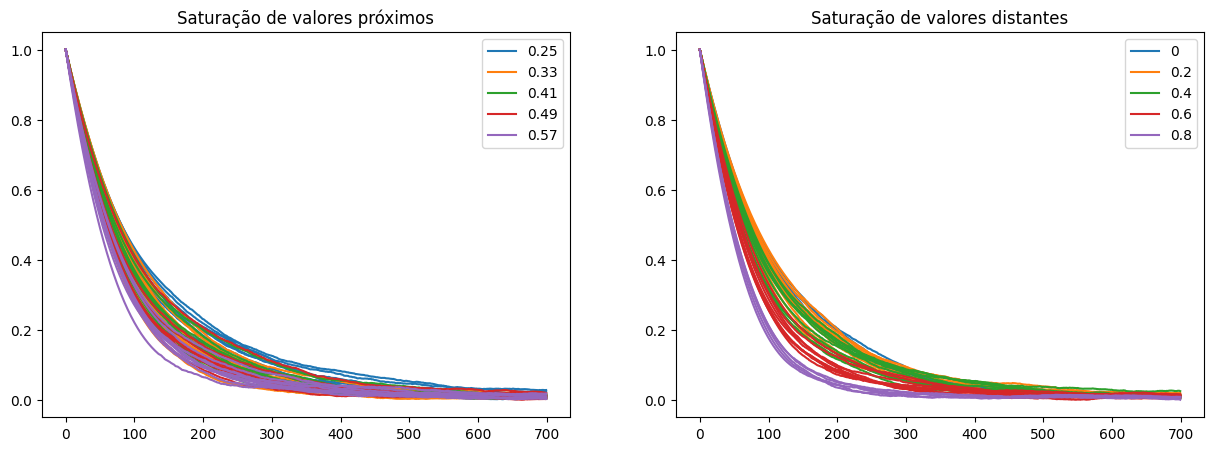

In [13]:
train_df = pd.read_csv('data_train_post_n_savgol.csv', sep="\t")
cmap = plt.cm.tab10
fig, ax = plt.subplots(1,2,figsize=(15,5))

for i,sat_oil in enumerate([.25,.33,.41,.49,.57]):
    sel_train_df = train_df[train_df['y']==sat_oil]
    ax[0].plot(range(700),sel_train_df.iloc[0,:700], c=cmap(i%10), label=f'{str(sat_oil)}')
    for j in range(1,len(sel_train_df)):
        ax[0].plot(range(700),sel_train_df.iloc[j,:700], c=cmap(i%10))
ax[0].legend()
ax[0].set_title('Saturação de valores próximos')

for i,sat_oil in enumerate([0,.2,.4,.6,.8]):
    sel_train_df = train_df[train_df['y']==sat_oil]
    ax[1].plot(range(700),sel_train_df.iloc[0,:-1], c=cmap(i%10), label=f'{str(sat_oil)}')
    for j in range(1,len(sel_train_df)):
        ax[1].plot(range(700),sel_train_df.iloc[j,:-1], c=cmap(i%10))
ax[1].legend()
ax[1].set_title('Saturação de valores distantes')
    
plt.show();

/tmp/ipykernel_362362/1184637871.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


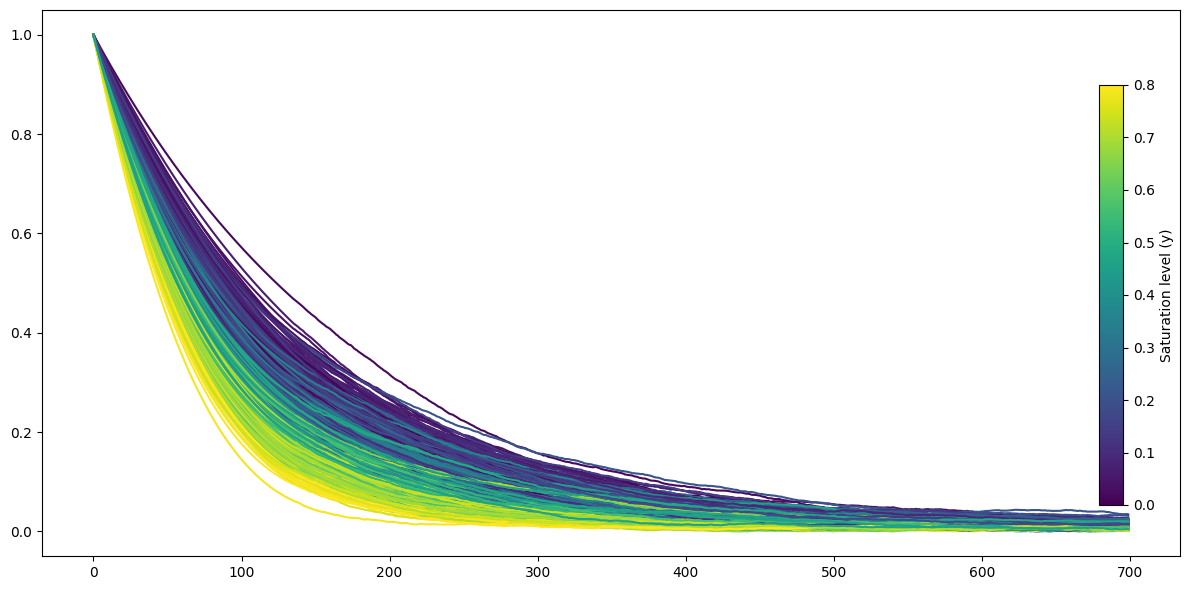

In [12]:
samples = train_df.sample(600, random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(samples.iterrows()):
    signal = row.iloc[:-1].values
    y = row.iloc[-1]
    ax.plot(signal, color=cmap(norm(y)))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Eixo do colorbar ao lado do gráfico
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label("Saturation level (y)")

plt.tight_layout()
plt.show()
